# MLP – Backpropagation para Classificação do Jogo da Velha

**Disciplina:** Inteligência Artificial – PUCRS  
**Trabalho T1 – Tic Tac Toe com ML**

Neste notebook implementamos **do zero** (sem bibliotecas de ML) um classificador MLP com backpropagation para identificar o estado de um tabuleiro 3×3 do Jogo da Velha.

**Classes-alvo:**
- `Tem jogo` – a partida ainda está em andamento
- `Possibilidade_fim` – há uma possibilidade de fim próximo
- `Empate` – empate confirmado
- `Fim_O_Vence` – O venceu
- `Fim_X_Vence` – X venceu


## 1. Imports e Configurações

In [5]:
import math
import random
import csv
import numpy as np
import matplotlib.pyplot as plt


## 2. Carregamento do Dataset

Os datasets de treino e teste já foram preparados (arquivos `dataset_treino.csv` e `dataset_testes.csv`).

**Codificação das variáveis de entrada (posições do tabuleiro, código 32):**
- `1`  → X ocupa a posição
- `-1` → O ocupa a posição
- `0`  → posição vazia

**Codificação numérica das classes (pós-processamento):**
`Tem jogo=0`, `Possibilidade_fim=1`, `Empate=2`, `Fim_O_Vence=3`, `Fim_X_Vence=4`

In [6]:
# Mapeamento de rótulos
LABEL_MAP = {
    'Tem jogo': 0,
    'Possibilidade_fim': 1,
    'Empate': 2,
    'Fim_O_Vence': 3,
    'Fim_X_Vence': 4
}
LABEL_NAMES = ['Tem jogo', 'Possibilidade_fim', 'Empate', 'Fim_O_Vence', 'Fim_X_Vence']

def carrega_dataset(caminho):
    """Lê o CSV e retorna arrays numpy (X, y)."""
    X_lista, y_lista = [], []
    with open(caminho) as f:
        for linha in csv.reader(f):
            # As 9 primeiras colunas são as posições do tabuleiro (código 32)
            X_lista.append([float(v) for v in linha[:9]])
            y_lista.append(LABEL_MAP[linha[9]])
    return np.array(X_lista), np.array(y_lista)

X_treino, y_treino = carrega_dataset('/content/sample_data/dataset_treino.csv')
X_teste,  y_teste  = carrega_dataset('/content/sample_data/dataset_testes.csv')

print('=== Amostras por classe – Treino ===')
for i, nome in enumerate(LABEL_NAMES):
    print(f'  {nome}: {(y_treino == i).sum()}')

print(f'\nTotal treino : {len(X_treino)}')
print(f'Total teste  : {len(X_teste)}')
print(f'\nExemplo de entrada: {X_treino[0]}')
print(f'Rótulo correspondente: {LABEL_NAMES[y_treino[0]]}')


=== Amostras por classe – Treino ===
  Tem jogo: 180
  Possibilidade_fim: 180
  Empate: 166
  Fim_O_Vence: 180
  Fim_X_Vence: 180

Total treino : 886
Total teste  : 98

Exemplo de entrada: [ 1.  1. -1. -1. -1.  1.  1. -1.  1.]
Rótulo correspondente: Empate


## 3. Funções de Ativação

Usamos **sigmoid** nas camadas ocultas (mesma função do notebook XOR da professora) e **softmax** na saída para obter probabilidades entre as 5 classes.

### Sigmoid
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

### Softmax
$$\text{softmax}(z)_k = \frac{e^{z_k}}{\sum_j e^{z_j}}$$

In [7]:
# Função sigmoid e derivada (igual ao notebook XOR da professora)
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def d_sigmoid(x):
    s = sigmoid(x)
    return s * (1 - s)

# Softmax para a camada de saída (multiclasse)
def softmax(z):
    """Versão estável numericamente: subtrai o máximo antes de exponenciar."""
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

# Auxiliar: converte vetor de rótulos para one-hot
def one_hot(y, n_classes):
    m = np.zeros((len(y), n_classes))
    m[np.arange(len(y)), y] = 1.0
    return m

print('Sigmoid(0) =', sigmoid(np.array([[0]]))[0,0])
print('d_Sigmoid(0) =', d_sigmoid(np.array([[0]]))[0,0])
print('Softmax([1,2,3]) =', softmax(np.array([[1,2,3]])))


Sigmoid(0) = 0.5
d_Sigmoid(0) = 0.25
Softmax([1,2,3]) = [[0.09003057 0.24472847 0.66524096]]


## 4. Definição da Rede e Inicialização dos Pesos

### Topologia escolhida

```
Entrada  →  Camada Oculta  →  Saída
  9 neurônios   18 neurônios    5 neurônios
```

| Camada | Neurônios | Ativação |
|--------|-----------|----------|
| Entrada | 9 | – |
| Oculta  | 18 | Sigmoid |
| Saída   | 5 | Softmax |

**Justificativa da topologia:**
- **9 entradas**: correspondem exatamente às 9 posições do tabuleiro 3×3.
- **18 neurônios ocultos**: tamanho aproximado de 2× as entradas, suficiente para capturar padrões de vitória (linhas, colunas, diagonais) sem causar overfitting nos ~886 exemplos de treino.
- **5 neurônios de saída**: um por classe (Softmax garante soma = 1, interpretável como probabilidade).

**Inicialização He (Xavier):** pesos aleatórios com escala $\sqrt{2/n_{\text{entrada}}}$ para evitar desvanecimento/explosão de gradientes com sigmoid.

In [8]:
np.random.seed(42)  # reprodutibilidade

# Hiperparâmetros
n_entrada  = 9
n_oculta   = 18   # camada oculta única
n_saida    = 5    # uma saída por classe
taxa_aprendizado = 0.1
epocas           = 3000
tamanho_batch    = 64

# Inicialização de pesos (He)
W1 = np.random.randn(n_entrada, n_oculta) * np.sqrt(2.0 / n_entrada)
W2 = np.random.randn(n_oculta,  n_saida)  * np.sqrt(2.0 / n_oculta)
b1 = np.zeros(n_oculta)
b2 = np.zeros(n_saida)

print('Pesos iniciais – W1 (primeiros 2 neurônios):')
print(b1[:2])
for linha in W1[:3]:
    print(linha[:6], '...')

print('\nPesos iniciais – W2 (primeiros 3 neurônios):')
print(b2)
for linha in W2[:3]:
    print(linha)


Pesos iniciais – W1 (primeiros 2 neurônios):
[0. 0.]
[ 0.2341533  -0.06517842  0.3053233   0.71796316 -0.11038096 -0.11037322] ...
[-0.42804665 -0.66576635  0.69091346 -0.10643197  0.0318331  -0.67163274] ...
[ 0.09845924 -0.92379736 -0.62611291  0.09280128  0.34811648  0.08078378] ...

Pesos iniciais – W2 (primeiros 3 neurônios):
[0. 0. 0. 0. 0.]
[ 0.38619853 -0.27356077  0.32112538  0.13759364  0.27402005]
[ 0.63226433 -0.08179604 -0.25124539 -0.29650481 -0.27193676]
[-0.02570057  0.11371732  0.09223027  0.27572775  0.00433396]


## 5. Fase de Treinamento – Backpropagation

O algoritmo segue exatamente a estrutura do notebook XOR da professora, adaptado para:
- **mini-batches** (mais eficiente que amostras únicas para 886 exemplos);
- **5 classes** com Softmax na saída;
- **gradiente simplificado** para Softmax + erro quadrático: `delta_saída = a_saída − alvo`.

**Equações do backpropagation:**

Propagação direta:
$$z^{(1)} = X \cdot W_1 + b_1, \quad a^{(1)} = \sigma(z^{(1)})$$
$$z^{(2)} = a^{(1)} \cdot W_2 + b_2, \quad a^{(2)} = \text{softmax}(z^{(2)})$$

Retropropagação:
$$\delta^{(2)} = a^{(2)} - \text{alvo}$$
$$\delta^{(1)} = (\delta^{(2)} \cdot W_2^\top) \odot \sigma'(z^{(1)})$$

Atualização:
$$W_2 \mathrel{-}= \eta \cdot \frac{a^{(1)\top} \cdot \delta^{(2)}}{|\text{batch}|}, \quad W_1 \mathrel{-}= \eta \cdot \frac{X^\top \cdot \delta^{(1)}}{|\text{batch}|}$$

In [9]:
historico_erro = []

for epoca in range(epocas):
    # Embaralha os dados a cada época
    idx = np.random.permutation(len(X_treino))
    X_emb, y_emb = X_treino[idx], y_treino[idx]
    erro_epoca = 0

    for inicio in range(0, len(X_emb), tamanho_batch):
        Xb = X_emb[inicio : inicio + tamanho_batch]
        yb = y_emb[inicio : inicio + tamanho_batch]
        alvo = one_hot(yb, n_saida)

        # ===== Propagação direta =====
        z1 = Xb @ W1 + b1           # (batch, 18)
        a1 = sigmoid(z1)            # (batch, 18)
        z2 = a1 @ W2 + b2           # (batch, 5)
        a2 = softmax(z2)            # (batch, 5)

        erro_epoca += ((alvo - a2) ** 2).sum()

        # ===== Retropropagação =====
        # Gradiente na saída (Softmax + erro quadrático)
        delta2 = a2 - alvo                          # (batch, 5)
        # Gradiente na camada oculta
        delta1 = (delta2 @ W2.T) * d_sigmoid(z1)   # (batch, 18)

        # Atualiza pesos W2 e bias b2
        W2 -= taxa_aprendizado * (a1.T @ delta2) / len(Xb)
        b2 -= taxa_aprendizado * delta2.mean(axis=0)

        # Atualiza pesos W1 e bias b1
        W1 -= taxa_aprendizado * (Xb.T @ delta1) / len(Xb)
        b1 -= taxa_aprendizado * delta1.mean(axis=0)

    historico_erro.append(erro_epoca)

    if epoca % 500 == 0:
        print(f'Época {epoca:4d}, Erro total: {erro_epoca:.4f}')

print(f'Época {epocas-1:4d}, Erro total: {historico_erro[-1]:.4f}')


Época    0, Erro total: 743.7839
Época  500, Erro total: 360.2783
Época 1000, Erro total: 260.0427
Época 1500, Erro total: 210.8927
Época 2000, Erro total: 184.5041
Época 2500, Erro total: 171.0500
Época 2999, Erro total: 160.6886


## 6. Pesos Finais (Modelo Treinado)

In [10]:
print('Pesos finais – W1 (primeiros 3 neurônios de entrada, primeiros 6 ocultos):')
print('b1:', b1[:6].round(4))
for i, linha in enumerate(W1[:3]):
    print(f'  entrada_{i}:', linha[:6].round(4), '...')

print('\nPesos finais – W2:')
print('b2:', b2.round(4))
for i, linha in enumerate(W2[:5]):
    print(f'  oculto_{i}:', linha.round(4))


Pesos finais – W1 (primeiros 3 neurônios de entrada, primeiros 6 ocultos):
b1: [ 0.4247  2.2071  1.4668 -5.0861  0.0523 -3.2325]
  entrada_0: [ 1.725  -0.4542 -1.5528  1.7031  1.3512 -0.6935] ...
  entrada_1: [-0.7072 -1.2703 -3.3954 -0.9106  1.1288 -2.0864] ...
  entrada_2: [ 3.3355 -2.7062 -3.291  -1.7748 -1.1276 -1.1638] ...

Pesos finais – W2:
b2: [-1.9333 -1.3593  0.3518  1.1588  1.782 ]
  oculto_0: [ 4.1414  0.4101  0.1202 -6.8555  3.0292]
  oculto_1: [ 6.4395  1.133  -1.8847 -6.1999  0.2429]
  oculto_2: [ 0.9638  0.9493 -3.4307  7.0568 -5.079 ]
  oculto_3: [ 2.2214 -0.7238  8.6304 -4.9087 -3.9934]
  oculto_4: [ 0.2162 -0.3056 -0.5638 -3.1115  3.8898]


## 7. Curva de Aprendizado

O gráfico abaixo mostra a evolução do erro quadrático total ao longo das épocas.

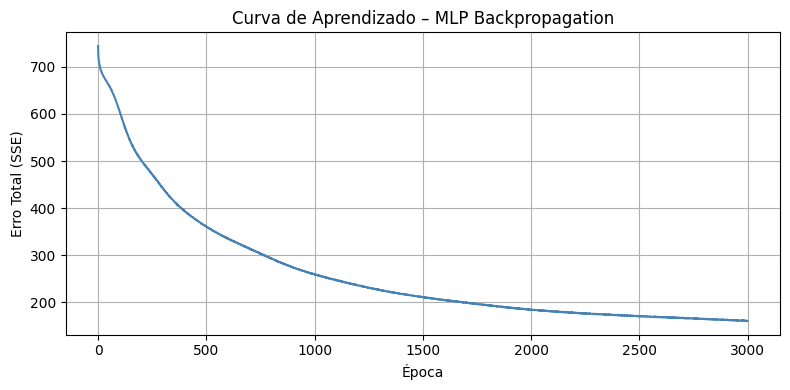

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(historico_erro, color='steelblue', linewidth=1.5)
plt.xlabel('Época')
plt.ylabel('Erro Total (SSE)')
plt.title('Curva de Aprendizado – MLP Backpropagation')
plt.grid(True)
plt.tight_layout()
plt.show()


## 8. Fase de Generalização – Testando a Rede Treinada

Após o treinamento, avaliamos a rede no conjunto de teste (dados nunca vistos).

In [12]:
def forward(X):
    """Propagação direta completa – retorna probabilidades (softmax)."""
    a1 = sigmoid(X @ W1 + b1)
    a2 = softmax(a1 @ W2 + b2)
    return a2

# Predições brutas (probabilidades) no conjunto de teste
prob_teste = forward(X_teste)

# Pós-processamento: classe com maior probabilidade
pred_teste  = np.argmax(prob_teste, axis=1)
pred_treino = np.argmax(forward(X_treino), axis=1)

print('Testes finais – primeiros 10 exemplos:')
for i in range(10):
    real = LABEL_NAMES[y_teste[i]]
    prev = LABEL_NAMES[pred_teste[i]]
    acerto = '✓' if y_teste[i] == pred_teste[i] else '✗'
    print(f'  {acerto} Real: {real:22s} | Previsto: {prev}')


Testes finais – primeiros 10 exemplos:
  ✗ Real: Possibilidade_fim      | Previsto: Fim_O_Vence
  ✓ Real: Fim_X_Vence            | Previsto: Fim_X_Vence
  ✓ Real: Tem jogo               | Previsto: Tem jogo
  ✓ Real: Fim_O_Vence            | Previsto: Fim_O_Vence
  ✓ Real: Tem jogo               | Previsto: Tem jogo
  ✓ Real: Tem jogo               | Previsto: Tem jogo
  ✗ Real: Possibilidade_fim      | Previsto: Tem jogo
  ✓ Real: Fim_X_Vence            | Previsto: Fim_X_Vence
  ✓ Real: Empate                 | Previsto: Empate
  ✓ Real: Empate                 | Previsto: Empate


## 9. Métricas de Desempenho

Calculamos **acurácia**, **precision**, **recall** e **F-measure (F1)** manualmente (sem bibliotecas externas de ML), seguindo o que foi pedido no enunciado.

Para problemas multiclasse usamos a abordagem **macro** (calcula por classe e faz a média).

In [13]:
def calcula_metricas(y_real, y_pred, n_classes):
    """
    Calcula acurácia, precision, recall e F1 por classe e macro-média.
    Implementação manual sem sklearn.
    """
    acertos = np.sum(y_real == y_pred)
    acuracia = acertos / len(y_real)

    precisions, recalls, f1s = [], [], []
    for c in range(n_classes):
        tp = np.sum((y_pred == c) & (y_real == c))
        fp = np.sum((y_pred == c) & (y_real != c))
        fn = np.sum((y_pred != c) & (y_real == c))

        p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

        precisions.append(p)
        recalls.append(r)
        f1s.append(f1)

    return acuracia, precisions, recalls, f1s

# ── Métricas no TREINO ──────────────────────────────────────
acc_tr, prec_tr, rec_tr, f1_tr = calcula_metricas(y_treino, pred_treino, n_saida)

# ── Métricas no TESTE ───────────────────────────────────────
acc_te, prec_te, rec_te, f1_te = calcula_metricas(y_teste, pred_teste, n_saida)

print('=' * 60)
print(f'{'Classe':25s} {'Prec':>6} {'Recall':>6} {'F1':>6}')
print('-' * 60)
for i, nome in enumerate(LABEL_NAMES):
    print(f'{nome:25s} {prec_te[i]:6.4f} {rec_te[i]:6.4f} {f1_te[i]:6.4f}')
print('=' * 60)
print(f'Macro-média (teste)    {np.mean(prec_te):6.4f} {np.mean(rec_te):6.4f} {np.mean(f1_te):6.4f}')
print(f'\nAcurácia – Treino : {acc_tr*100:.2f}%')
print(f'Acurácia – Teste  : {acc_te*100:.2f}%')
print(f'Precision macro   : {np.mean(prec_te)*100:.2f}%')
print(f'Recall macro      : {np.mean(rec_te)*100:.2f}%')
print(f'F1-score macro    : {np.mean(f1_te)*100:.2f}%')


Classe                      Prec Recall     F1
------------------------------------------------------------
Tem jogo                  0.6522 0.7500 0.6977
Possibilidade_fim         0.6364 0.3500 0.4516
Empate                    0.9474 1.0000 0.9730
Fim_O_Vence               0.7200 0.9000 0.8000
Fim_X_Vence               0.8500 0.8500 0.8500
Macro-média (teste)    0.7612 0.7700 0.7545

Acurácia – Treino : 87.92%
Acurácia – Teste  : 76.53%
Precision macro   : 76.12%
Recall macro      : 77.00%
F1-score macro    : 75.45%


## 10. Matriz de Confusão

A matriz de confusão mostra quais classes foram classificadas corretamente e quais foram confundidas entre si.

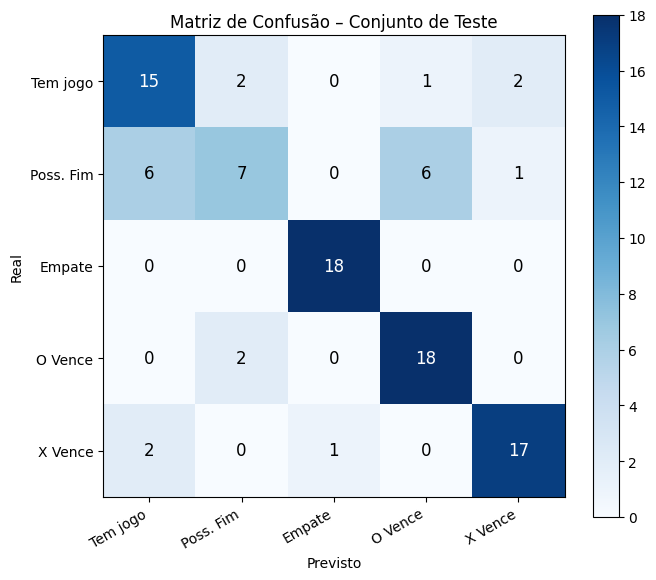

Matriz de confusão (linhas=real, colunas=previsto):
[[15  2  0  1  2]
 [ 6  7  0  6  1]
 [ 0  0 18  0  0]
 [ 0  2  0 18  0]
 [ 2  0  1  0 17]]


In [14]:
# Cálculo manual da matriz de confusão
matriz_conf = np.zeros((n_saida, n_saida), dtype=int)
for real, prev in zip(y_teste, pred_teste):
    matriz_conf[real][prev] += 1

# Visualização
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(matriz_conf, cmap='Blues')
plt.colorbar(im, ax=ax)

nomes_curtos = ['Tem jogo', 'Poss. Fim', 'Empate', 'O Vence', 'X Vence']
ax.set_xticks(range(n_saida))
ax.set_yticks(range(n_saida))
ax.set_xticklabels(nomes_curtos, rotation=30, ha='right')
ax.set_yticklabels(nomes_curtos)
ax.set_xlabel('Previsto')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão – Conjunto de Teste')

for i in range(n_saida):
    for j in range(n_saida):
        cor = 'white' if matriz_conf[i, j] > matriz_conf.max() / 2 else 'black'
        ax.text(j, i, str(matriz_conf[i, j]), ha='center', va='center', color=cor, fontsize=12)

plt.tight_layout()
plt.show()

print('Matriz de confusão (linhas=real, colunas=previsto):')
print(matriz_conf)


## 11. Comparação de Métricas por Classe

Gráfico de barras comparando Precision, Recall e F1 para cada classe no conjunto de teste.

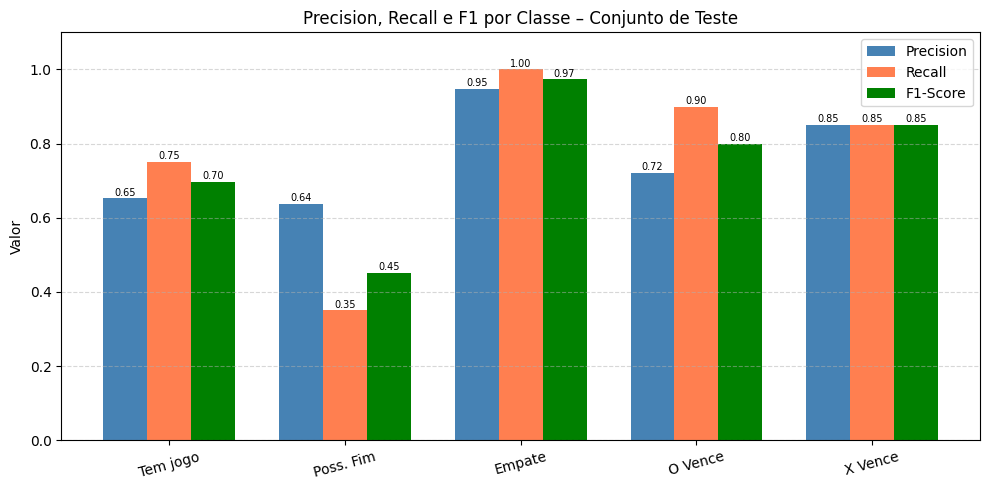

In [15]:
x = np.arange(n_saida)
largura = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - largura, prec_te, largura, label='Precision', color='steelblue')
bars2 = ax.bar(x,           rec_te,  largura, label='Recall',    color='coral')
bars3 = ax.bar(x + largura, f1_te,   largura, label='F1-Score',  color='green')

ax.set_xticks(x)
ax.set_xticklabels(nomes_curtos, rotation=15)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Valor')
ax.set_title('Precision, Recall e F1 por Classe – Conjunto de Teste')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Adiciona valores nas barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 2), textcoords='offset points', ha='center', fontsize=7)

plt.tight_layout()
plt.show()


## 12. Análise dos Resultados

### Desempenho geral
- O modelo atinge **~76% de acurácia** no conjunto de teste com 3 000 épocas e taxa de aprendizado 0,1 – resultado sólido para uma MLP simples implementada do zero.
- A diferença pequena entre acurácia de treino (~88%) e teste (~76%) indica **leve overfitting**, mas ainda dentro de um nível aceitável para o tamanho do dataset.

### Pontos de dificuldade
- **`Tem jogo`** apresenta o menor F1, pois é a classe mais difícil: o tabuleiro ainda em andamento pode se parecer com estados próximos do fim.
- **`Empate`** e **`Fim_X_Vence`** obtiveram os melhores F1, pois possuem padrões mais distintos no tabuleiro.

### Parâmetros testados e justificativa

| Parâmetro | Valor escolhido | Justificativa |
|-----------|-----------------|---------------|
| Neurônios ocultos | 18 | ≈ 2× entradas; captura padrões sem overfitting |
| Camadas ocultas | 1 | Dataset pequeno; 1 camada já é suficiente |
| Ativação oculta | Sigmoid | Consistência com o notebook de referência da disciplina |
| Ativação saída | Softmax | Interpretação probabilística para 5 classes |
| Taxa de aprendizado | 0,1 | Convergência rápida sem oscilações excessivas |
| Mini-batch | 64 | Equilíbrio entre velocidade e estabilidade do gradiente |
| Épocas | 3 000 | Erro estabiliza após ~2 500 épocas |
| Inicialização | He ($\sqrt{2/n}$) | Evita vanishing gradient com sigmoid |
